# Day 10 — Model Evaluation & Performance Metrics

**Coding + Coding Explanation**

## 1. Import Libraries

We use Scikit-Learn metrics to evaluate classification and regression models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.datasets import load_iris
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


# PART A — CLASSIFICATION EVALUATION

We will predict student Pass/Fail and evaluate the classification model.

## 2. Create Classification Dataset

In [2]:
data = {
    "Hours": [1,2,3,4,5,6,7,8,9,10,2,3,4,6,7,8,9,10,5,4],
    "Attendance": [50,55,60,65,70,75,80,85,90,95,52,62,68,76,82,88,92,96,72,66],
    "Result": [0,0,0,0,1,1,1,1,1,1,0,0,1,1,1,1,1,1,1,0]
}
df = pd.DataFrame(data)
print(df.head())


   Hours  Attendance  Result
0      1          50       0
1      2          55       0
2      3          60       0
3      4          65       0
4      5          70       1


## 3. Separate Features and Target

In [3]:
X = df[["Hours", "Attendance"]]
y = df["Result"]


## 4. Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print("Training:", X_train.shape)
print("Testing :", X_test.shape)


Training: (15, 2)
Testing : (5, 2)


## 5. Train Logistic Regression

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Actual   :", y_test.values)
print("Predicted:", y_pred)


Actual   : [0 1 1 0 1]
Predicted: [0 1 1 0 1]


## 6. Confusion Matrix

A confusion matrix compares actual and predicted classes.

In [6]:
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[2 0]
 [0 3]]


## 7. Visualize Confusion Matrix

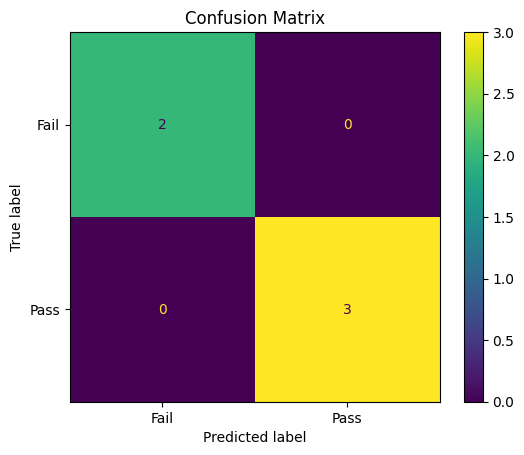

In [7]:
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)
display.plot()
plt.title("Confusion Matrix")
plt.show()


## 8. TP, TN, FP, FN

For binary classification the matrix is `[[TN, FP], [FN, TP]]`.

In [8]:
TN, FP, FN, TP = cm.ravel()

print("True Negative :", TN)
print("False Positive:", FP)
print("False Negative:", FN)
print("True Positive :", TP)


True Negative : 2
False Positive: 0
False Negative: 0
True Positive : 3


## 9. Accuracy

Accuracy = `(TP + TN) / (TP + TN + FP + FN)`

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)


Accuracy: 1.0
Accuracy (%): 100.0


## 10. Precision

Precision answers: **When the model predicts Positive, how often is it correct?**

In [10]:
precision = precision_score(y_test, y_pred, zero_division=0)
print("Precision:", precision)


Precision: 1.0


## 11. Recall

Recall answers: **Of all actual Positive cases, how many did the model identify?**

In [11]:
recall = recall_score(y_test, y_pred, zero_division=0)
print("Recall:", recall)


Recall: 1.0


## 12. F1-Score

F1 balances Precision and Recall.

In [12]:
f1 = f1_score(y_test, y_pred, zero_division=0)
print("F1-Score:", f1)


F1-Score: 1.0


## 13. Classification Report

In [13]:
print(
    classification_report(
        y_test, y_pred,
        target_names=["Fail", "Pass"],
        zero_division=0
    )
)


              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         2
        Pass       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



# PART B — REGRESSION EVALUATION

We will predict a student's score from study hours.

## 14. Create Regression Dataset

In [14]:
data = {
    "Hours": [1,2,3,4,5,6,7,8,9,10],
    "Score": [35,42,48,55,61,68,74,81,88,94]
}
df_reg = pd.DataFrame(data)
print(df_reg)


   Hours  Score
0      1     35
1      2     42
2      3     48
3      4     55
4      5     61
5      6     68
6      7     74
7      8     81
8      9     88
9     10     94


## 15. Train/Test Split

In [15]:
X = df_reg[["Hours"]]
y = df_reg["Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 16. Train Linear Regression

In [16]:
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_test)

print("Actual   :", y_test.values)
print("Predicted:", y_pred)


Actual   : [88 42]
Predicted: [87.43103448 41.56896552]


## 17. MAE

MAE is the average absolute prediction error. Lower is generally better.

In [17]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)


MAE: 0.5


## 18. MSE

MSE averages squared prediction errors, so large errors receive more penalty.

In [18]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)


MSE: 0.2547562425683712


## 19. RMSE

RMSE is the square root of MSE and is expressed in the target's units.

In [19]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)


RMSE: 0.5047338333898087


## 20. R² Score

R² measures how much variation in the target is explained by the model relative to a baseline.

In [20]:
r2 = r2_score(y_test, y_pred)
print("R²:", r2)


R²: 0.999518419201194


## 21. Regression Metrics Together

In [21]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))


MAE : 0.5
MSE : 0.2547562425683712
RMSE: 0.5047338333898087
R²  : 0.999518419201194


## 22. Actual vs Predicted Plot

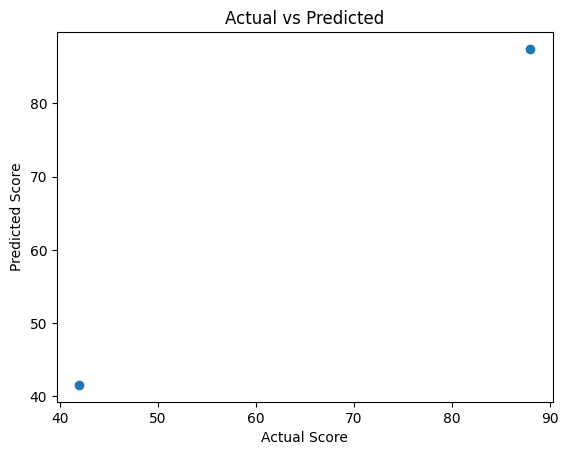

In [22]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted")
plt.show()


# PART C — OVERFITTING VS UNDERFITTING

Training performance much higher than testing performance can indicate overfitting.

## 23. Create Polynomial Dataset

In [23]:
X = np.arange(1, 21).reshape(-1, 1)

y = (
    3 * X.ravel()
    + 0.5 * X.ravel() ** 2
    + np.random.default_rng(42).normal(0, 5, 20)
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


## 24. Simple Linear Model

In [24]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Training R²:", linear_model.score(X_train, y_train))
print("Testing R² :", linear_model.score(X_test, y_test))


Training R²: 0.9704398553354121
Testing R² : 0.9235304679197833


## 25. Complex Polynomial Model

In [25]:
poly_model = make_pipeline(
    PolynomialFeatures(degree=10),
    LinearRegression()
)

poly_model.fit(X_train, y_train)

print("Training R²:", poly_model.score(X_train, y_train))
print("Testing R² :", poly_model.score(X_test, y_test))


Training R²: 0.998523146202437
Testing R² : 0.9711591287169926


# PART D — CROSS-VALIDATION

K-Fold Cross-Validation evaluates a model across multiple train/validation splits.

## 26. 5-Fold Cross-Validation

In [26]:
iris = load_iris()

X = iris.data
y = iris.target

cv_model = LogisticRegression(max_iter=1000)

scores = cross_val_score(
    cv_model,
    X, y,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())


CV Scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Mean CV Accuracy: 0.9733333333333334


# 🎯 Day 10 Final Flow

**Classification:** `Model → Predictions → Confusion Matrix → Accuracy / Precision / Recall / F1`

**Regression:** `Model → Predictions → Errors → MAE / MSE / RMSE / R²`

**Generalization:** `Training Performance + Testing Performance + Cross-Validation`